In [1]:
import GWDALI as gw
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


### Setting detectors network

In [2]:
# 2nd Generation Detectors

det1 = {'name':'LIGO', 'lon':-119.41, 'lat': 46.46, 'rot': 216.00, 'shape':90}
det2 = {'name':'LIGO', 'lon':-90.77, 'lat': 30.56, 'rot': 288.00, 'shape':90}
det3 = {'name':'Virgo', 'lon':10.50, 'lat': 43.63, 'rot': 161.00, 'shape':90}
det4 = {'name':'Kagra', 'lon':137.31, 'lat': 36.41, 'rot': 118.31, 'shape':90}

# 3rd Generation Detectors

# Cosmic Explorer Coordinates
# https://cosmicexplorer.org/celocations.html
lon_CE_A = -125.0891
lat_CE_A = 45.64555

lon_CE_B = -94.
lat_CE_B = 29.

# Einstein Telecope Coordinates (Vaalserberg)
lon_ET = 6.02138
lat_ET = 50.75345

det_CE_A = {'name':'CE_20km','lon':lon_CE_A, 'lat':lat_CE_A, 'rot':190, 'shape':90}
det_CE_B = {'name':'CE_40km','lon':lon_CE_B, 'lat':lat_CE_B, 'rot':250, 'shape':90}

det_ET1 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':0, 'shape':60}
det_ET2 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':120, 'shape':60}
det_ET3 = {'name':'ET','lon':lon_ET, 'lat':lat_ET, 'rot':-120, 'shape':60}

detectors = [det1,det2,det3,det4, det_CE_A, det_CE_B, det_ET1, det_ET2, det_ET3]

### Plotting detectors coordinates/oriantation

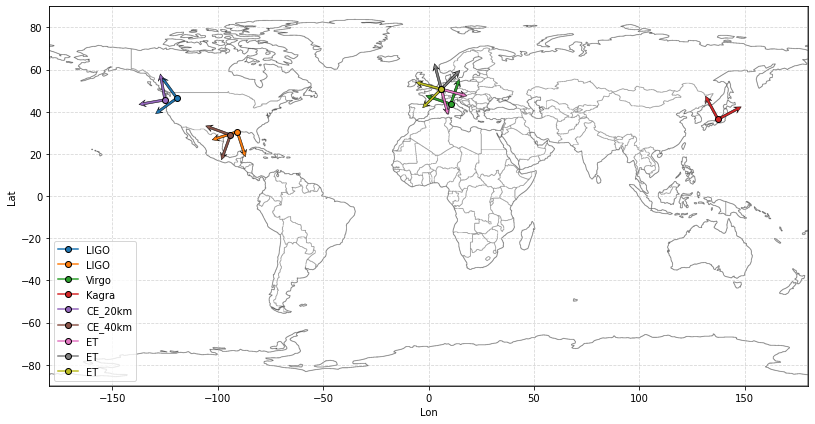

In [3]:
fig = gw.draw_detectors(detectors)

### Plotting Antenna Pattern Response
$$F\equiv \sqrt{ \sum_{a=1}^{N_{dets}}(F_{+,a})^2+(F_{\times,a})^2}$$

  2%|▏         | 1/50 [00:00<00:06,  7.69it/s]

>> Getting Detector Response ...


100%|██████████| 50/50 [00:00<00:00, 391.41it/s]


Text(0.5, 0.98, '$F = \\sqrt{\\sum_a (F_{+,a}^2+F_{\\times,a}^2)}$')

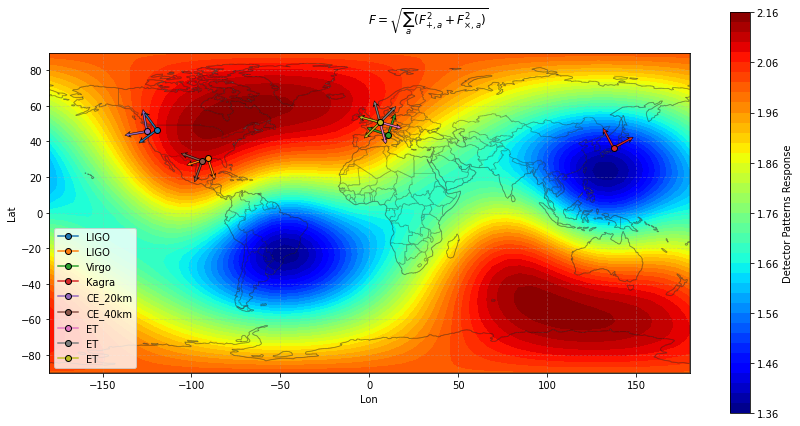

In [4]:
fig = gw.get_map(detectors,plot_map=True)
plt.suptitle("$F = \\sqrt{\\sum_a (F_{+,a}^2+F_{\\times,a}^2)}$")

### Getting Map Data for Alternative Plot (Aitoff Projection Map)

In [5]:
xx, yy, F = gw.get_map(detectors,plot_map=False)

  0%|          | 0/50 [00:00<?, ?it/s]

>> Getting Detector Response ...


100%|██████████| 50/50 [00:00<00:00, 406.96it/s]


In [6]:
print(xx.min(), xx.max())
print(yy.min(), yy.max())

xx2 = xx[:, :-1]
yy2 = yy[:, :-1]
F2  = F[:, :-1]

-180.0 180.0
-90.0 90.0


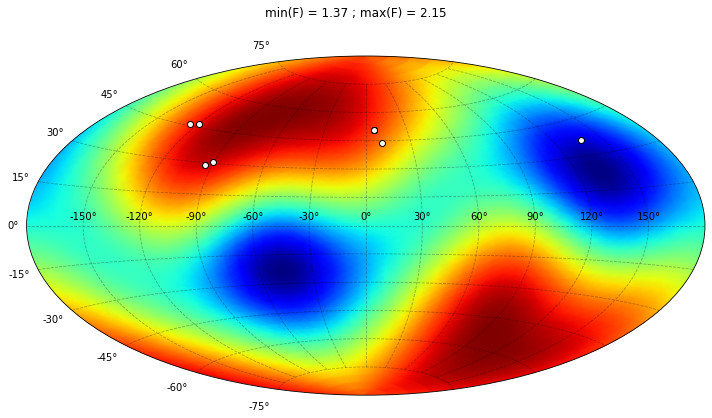

In [7]:
rad = np.pi/180

norm = mcolors.Normalize(vmin=np.min(F),vmax=np.max(F))

fig = plt.figure(figsize=(10,6))
ax = plt.subplot(111,projection='aitoff')
plt.suptitle(f"min(F) = {np.min(F):.2f} ; max(F) = {np.max(F):.2f}")

c = ax.pcolormesh(
    xx * rad,
    yy * rad,
    F,
    cmap='jet',
    shading='gouraud'
)

for det in detectors:
    lon = det['lon']*rad
    lat = det['lat']*rad
    plt.plot(lon,lat,'wo',mec='k')
    
plt.grid(ls='--',color='k',alpha=0.3)

plt.tight_layout()

### Viewing Detectors Sensitivities

Text(0, 0.5, 'Characteristic Strain')

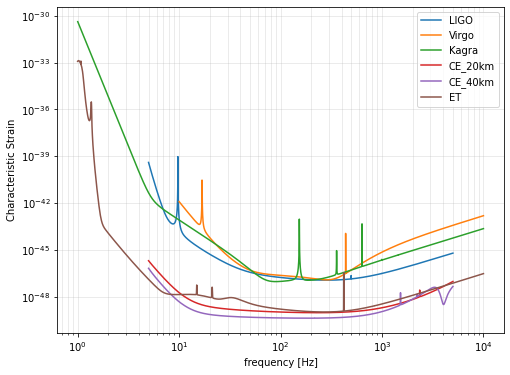

In [8]:
fig = plt.figure(figsize=(8,6))
names = []
for det in detectors:
    if not det["name"] in names:
        Sn, freq = gw.lib.Tensors.get_Sn(det) # Use this command to get detectors sensitivities (One-Sided Noise Power Specral Density)
        Sc = np.sqrt(freq*Sn)
        plt.loglog(freq,Sn,label=det['name'])
        names.append(det["name"])

plt.legend()
plt.grid(which='both',alpha=.3)
plt.xlabel('frequency [Hz]')
plt.ylabel('Characteristic Strain')

### Adding New Detectors (Sensitivities provided by the user)
Here I'm going to read the Amplitude Spectum Density (ASD) of some detector (from the file "voyager.txt") and its corresponding frequencies values.

In [9]:
freq, ASD = np.loadtxt("Sn_voyager.txt").T
Sn = ASD**2

The new detector dictionary need to have an entry "name" different than the availables ["ET", "CE", "CE_20km", "CE_40km", "LIGO", "Virgo", "KARGRA"] and new entries "Sn" with an array of one-sided noise power spectrum, and "freq" with its corresponding frequencies.

In [10]:
# Putting Voyager on Arizona, US
lat, lon = 35.0000, -116.0000
new_det = { "name":"Voyager", "lon":lon, "lat":lat, "rot":30, "shape":90, "Sn":Sn, "freq":freq }

Testing the new detector curve with name "Voyager".

Reading a new detector: Voyager


Text(0, 0.5, 'Characteristic Strain')

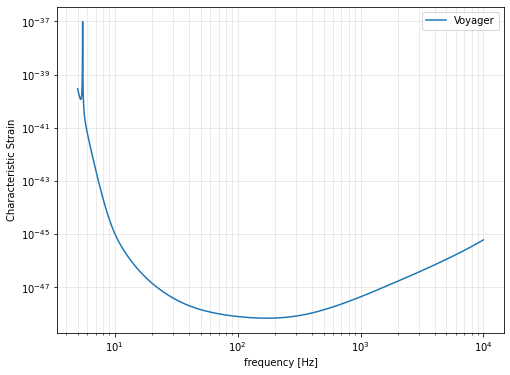

In [11]:
dets = [] ; names = []

fig = plt.figure(figsize=(8,6))
for det in [new_det]:
    name = det['name']
    
    Sn, freq = gw.lib.Tensors.get_Sn(det) # Use this command to get detectors sensitivities (One-Sided Noise Power Specral Density)
    Sc = np.sqrt(freq*Sn)

    plt.loglog(freq,Sn,label=name)

plt.legend()
plt.grid(which='both',alpha=.3)
plt.xlabel('frequency [Hz]')
plt.ylabel('Characteristic Strain')

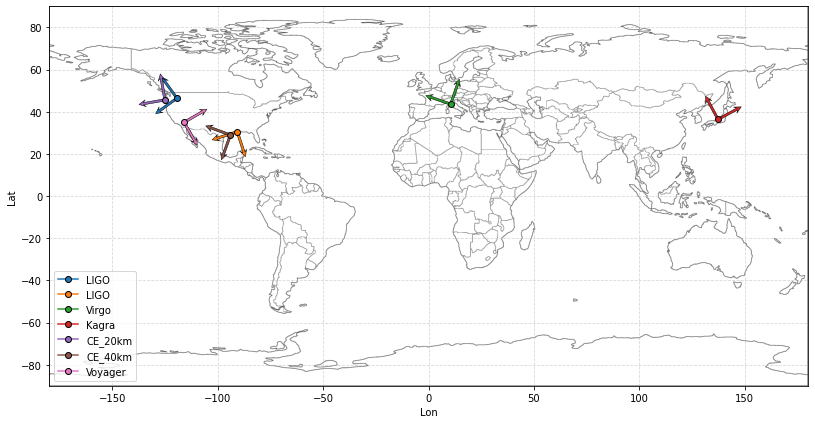

In [12]:
detectors2 = [det1,det2,det3,det4, det_CE_A, det_CE_B, new_det] # Subistituting ET by Voyager

fig = gw.draw_detectors(detectors2)